# **Distributed TPU Training with PyTorch/XLA for Animal Pose Estimation**

This notebook presents a complete pipeline for training, evaluation, and inference on **TPUs** using **PyTorch/XLA**. Distributed training is essential as datasets grow larger and models scale to millions or even billions of parameters, such as modern **VLMs** and **LLMs**, since training on a single accelerator (like a single GPU or TPU core) can become inefficient, extremely slow, and memory constrained.

In this specific case, distributed training is applied to an **animal pose estimation** task using a **bottom-up** approach, where the model predicts keypoints via heatmaps, generating output maps with the same spatial resolution as the input images. This type of task demands significantly more computational power than other computer vision tasks, such as image classification, object detection, segmentation, or others pose estimation methods, making it an excellent scenario to benchmark PyTorch/XLA's distributed training performance.

#### **Context and Hardware Comparison**

The same task, using the [CUB-200-2011](https://www.vision.caltech.edu/datasets/cub_200_2011/) dataset and a model with over **100 million parameters**, was previously implemented in my repository using distributed training with **TensorFlow** on Google Colab's **TPU v2-8**, with an input resolution of **(384, 384)**. 

In this notebook, training is performed on Kaggle's newer **TPU v5e-8** using the same input size. The goal is to demonstrate that **PyTorch/XLA** is a highly efficient framework for distributed training, capable of achieving performance that can even surpass a highly optimized **TensorFlow** pipeline on 8-core TPUs.

For this and other Deep Learning projects, you can visit my repository: [**Computer Vision**](https://github.com/JersonGB22/ComputerVision).

## **Environment Setup and Data Preparation**

In [ ]:
!pip install timm torchmetrics albumentations plotly gdown github-clone kaleido==0.2.1 -q

# Uninstall TensorFlow to avoid conflicts with PyTorch/XLA
!pip uninstall -y tensorflow -q

The **CUB-200-2011** dataset download and detailed preprocessing for pose estimation were completed in the following notebook: [**Preprocessing_CUB-200-2011**](https://github.com/JersonGB22/PoseEstimation-TensorFlow-PyTorch/blob/main/Preprocessing/Preprocessing_CUB-200-2011.ipynb). Additionally, three utility scripts are provided in the **utils** folder of this [repository](https://github.com/JersonGB22/PoseEstimation-TensorFlow-PyTorch/).
These scripts implement data augmentation, dataset creation, model construction, learning rate scheduling, loss and metrics, and visualization utilities for predictions and training/validation curves.

In [2]:
# Download the utils folder containing the helper scripts
!ghclone https://github.com/JersonGB22/PoseEstimation-TensorFlow-PyTorch/tree/main/pytorch_xla_ddp/utils

# Download and extract the CUB-200-2011 dataset
!gdown 1lNNnxgHV0N7UqXo3vh_84Wd08LENsUyL
!unzip -q CUB-200-2011.zip

Cloning into 'utils'...
done.
Downloading...
From (original): https://drive.google.com/uc?id=1lNNnxgHV0N7UqXo3vh_84Wd08LENsUyL
From (redirected): https://drive.google.com/uc?id=1lNNnxgHV0N7UqXo3vh_84Wd08LENsUyL&confirm=t&uuid=9a230b89-ca52-4d95-8d60-5fda958cb854
To: /content/CUB-200-2011.zip
100% 1.14G/1.14G [00:14<00:00, 78.4MB/s]


In [ ]:
import torch_xla
torch_xla.__version__

'2.8.0'

## **Defining the PyTorch/XLA Training Script**

In [ ]:
%%writefile train_xla.py

import os
os.environ.pop("TPU_PROCESS_ADDRESSES", None)

import warnings
warnings.filterwarnings("ignore")

import torch
from torch.utils.data import DataLoader
from torch.utils.data.distributed import DistributedSampler
from torchmetrics.classification import Accuracy
from torchmetrics.aggregation import MeanMetric

import torch_xla
import torch_xla.runtime as xr
from torch_xla.core import xla_model as xm
import torch_xla.distributed.parallel_loader as pl
import torch_xla._internal.tpu as tpu

from utils.data_module import PoseDataset, heatmaps_to_keypoints
from utils.model_module import (
    ConvNeXtPoseUNet, polynomial_lr_scheduler,
    PoseLoss, OKSMetric, PCKMetric
)
import argparse
import pandas as pd
import numpy as np
from tqdm import tqdm
import json
import os


def parse_args(cli_args: list[str] | None = None) -> argparse.Namespace:
    """
    Parses command-line arguments for XLA training. This function defines and parses arguments
    needed for distributed training, data loading, model configuration, and evaluation.

    Args:
        cli_args: A list of string arguments to parse. If None, defaults to 'sys.argv[1:]'.

    Returns:
        An object containing all parsed and processed arguments.
    """
    p = argparse.ArgumentParser(description="PyTorch/XLA distributed TPU training for pose estimation.")

    # General setup
    p.add_argument(
        "--run_mode", default="training", type=str,
        choices=["training", "evaluation", "inference"],
        help="Execution mode: training, evaluation or inference."
    )
    p.add_argument(
        "--single_process", action="store_true", default=False,
        help="Debug flag to run only in one process."
    )

    # Dataset setup
    p.add_argument(
        "--data_dir", default=os.getcwd(), type=str,
        help="Path to the dataset directory (must contain 'metadata.json')."
    )
    p.add_argument(
        "--batch_size", default=16, type=int,
        help="Global batch size."
    )
    p.add_argument(
        "--num_workers", default=os.cpu_count() // 2, type=int,
        help="Global number of data loader workers."
    )
    p.add_argument(
        "--img_mean", nargs=3, default=[0.485, 0.456, 0.406], type=float,
        help="Mean for image normalization. (Default: ConvNeXtBase)."
    )
    p.add_argument(
        "--img_std", nargs=3, default=[0.229, 0.224, 0.225], type=float,
        help="Std deviation for image normalization. (Default: ConvNeXtBase)."
    )
    p.add_argument(
        "--img_size", nargs=2, default=[384, 384], type=int,
        help="Dimensions to resize images: (height, width)."
    )
    p.add_argument(
        "--kernel_size", nargs=2, default=[49, 49], type=int,
        help="Gaussian kernel size for heatmap generation."
    )
    p.add_argument(
        "--heatmap_sigma", default=9.0, type=float,
        help="Standard deviation for the Gaussian heatmap."
    )

    # Training setup
    p.add_argument(
        "--ckpt_dir", default=os.path.join(os.getcwd(), "ckpt"), type=str,
        help="Directory to save model checkpoints."
    )
    p.add_argument(
        "--resume_ckpt", action="store_true", default=False,
        help="Resume training from the latest checkpoint if set."
    )
    p.add_argument(
        "--epochs", default=10, type=int,
        help="Number of training epochs."
    )
    p.add_argument(
        "--lr0", default=1e-3, type=float,
        help="Initial learning rate."
    )
    p.add_argument(
        "--lrf", default=1e-4, type=float,
        help="Final learning rate for scheduler."
    )
    p.add_argument(
        "--power", default=2.0, type=float,
        help="Polynomial decay exponent for learning rate scheduler."
    )
    p.add_argument(
        "--patience", default=1, type=int,
        help="Epochs with no improvement before early stopping."
    )
    p.add_argument(
        "--monitor", default="val_oks", type=str,
        help="Metric to monitor for early stopping."
    )
    p.add_argument(
        "--mode", default="max", type=str,
        help="Whether to minimize or maximize the monitored metric."
    )

    # Evaluation and inference setup
    p.add_argument(
        "--eval_set", default="val", type=str, choices=["train", "val", "test"],
        help="Dataset split for validation in 'training' or 'evaluation' mode."
    )
    p.add_argument(
        "--inf_set", default="val", type=str, choices=["train", "val", "test"],
        help="Dataset split to run inference on."
    )
    p.add_argument(
        "--inf_steps", default=None, type=int,
        help="Total steps (batches) for inference. If None, evaluates the entire set."
    )

    # Metrics setup
    p.add_argument(
        "--oks_sigmas", nargs="+", default=None, type=float,
        help="OKS sigmas of length nkpts. If None, defaults to 1/nkpts for all."
    )
    p.add_argument(
        "--alpha", default=0.05, type=float,
        help="Threshold for PCK metric."
    )

    args = p.parse_args(cli_args)

    # Load metadata from the dataset directory
    with open(os.path.join(args.data_dir, "metadata.json")) as f:
        metadata = json.load(f)

    # Attach metadata-derived fields to args
    args.symmetric_kpts = metadata["symmetric_kpts"]
    args.skeleton = metadata["skeleton"]
    args.nkpts = metadata["nkpts"]

    # Convert normalization params to torch tensors
    args.img_mean = torch.tensor(args.img_mean, dtype=torch.float32)
    args.img_std = torch.tensor(args.img_std, dtype=torch.float32)

    # If oks_sigmas was not provided, use uniform defaults
    if args.oks_sigmas is None:
        args.oks_sigmas = np.ones(args.nkpts) / args.nkpts

    return args


def build_data_pipeline(
    args: argparse.Namespace,
    rank: int,
    device: torch.device,
    split: str = "train",
    training: bool = True
) -> tuple[PoseDataset, DistributedSampler | None, DataLoader, pl.MpDeviceLoader]:
    """
    Initializes the data pipeline for a specific PyTorch/XLA device.

    Args:
        args: Parsed command-line arguments.
        rank: The global rank of the current process (0 to world_size - 1).
        device: The XLA device for the current rank.
        split: The dataset split to load.
        training: If True, enables training mode (e.g., data augmentation, shuffling).

    Returns:
        A tuple containing the dataset, sampler, dataloader and MpDeviceLoader.
    """
    dataset = PoseDataset(args, split, training)
    if args.world_size > 1:
        sampler = DistributedSampler(
            dataset,
            num_replicas=args.world_size,
            rank=rank,
            shuffle=training,
            drop_last=True
        )
    else:
        sampler = None

    loader = DataLoader(
        dataset,
        batch_size=args.batch_size // args.world_size,
        shuffle=(sampler is None) and training,
        sampler=sampler,
        num_workers=args.num_workers // args.world_size,
        drop_last=training
    )
    device_loader = pl.MpDeviceLoader(loader, device)

    # Print dataset summary only on the master process
    if xm.is_master_ordinal():
        # Calculate total dropped records
        deleted = len(dataset) % args.world_size
        if training:
            deleted += ((len(dataset) // args.world_size) % (args.batch_size // args.world_size)) * args.world_size

        tqdm.write(
            f"{split.capitalize().rjust(5) if args.run_mode == 'training' else split.capitalize()} dataset: "
            f"size={len(dataset)}, "
            f"deleted_records={deleted}"
        )

    return dataset, sampler, loader, device_loader


def dist_sync_fn(state: torch.Tensor, group=None) -> list[torch.Tensor]:
    """
    A custom synchronization function for torchmetrics using XLA's mesh_reduce.
    """
    state = xm.mesh_reduce("sync_metric", state, list)
    return state


def distributed_available_fn() -> bool:
    """
    Checks if XLA distributed training is active.
    """
    return xr.world_size() > 1


class XLATrainer():
    """
    A high-level trainer class for PyTorch/XLA (TPU) training. This class encapsulates the entire
    training, evaluation, and inference lifecycle for a pose estimation model. It handles XLA setup,
    model and metric initialization, checkpointing, and results aggregation.

    Args:
        rank: The global rank of the current process.
        device: The device for the current rank.
        args: Parsed command-line arguments.
    """

    def __init__(self, rank: int, device: torch.device, args: argparse.Namespace):
        self.rank = rank
        self.device = device
        self.args = args

        self.model = ConvNeXtPoseUNet(args.nkpts).to(device)
        if (args.run_mode == "training") and (not args.resume_ckpt):
            # Ensure all replicas start from the same parameters when not resuming
            xm.broadcast_master_param(self.model)

        # Instantiate metrics and loss function. TorchMetrics handles XLA synchronization.
        self.criterion = PoseLoss
        self.loss_metric = MeanMetric(
            dist_sync_fn=dist_sync_fn,
            distributed_available_fn=distributed_available_fn
        ).to(device)

        self.oks_metric = OKSMetric(
            args.oks_sigmas,
            dist_sync_fn=dist_sync_fn,
            distributed_available_fn=distributed_available_fn
        ).to(device)
        self.pck_metric = PCKMetric(
            args.alpha,
            dist_sync_fn=dist_sync_fn,
            distributed_available_fn=distributed_available_fn
        ).to(device)
        self.acc_metric = Accuracy(
            task="binary",
            dist_sync_fn=dist_sync_fn,
            distributed_available_fn=distributed_available_fn
        ).to(device)

    def run_epoch(
        self,
        device_loader: pl.MpDeviceLoader,
        phase: str = "train",
        training: bool = True
    ) -> dict[str, float]:
        """
        Runs one epoch of training or validation.

        Args:
            loader: The DataLoader for the epoch.
            phase: Name of the phase ('train', 'val' or 'test').
            training: True for training, False for evaluation.

        Returns:
            Metric results from the epoch.
        """
        # Switch model mode depending on phase
        self.model.train() if training else self.model.eval()

        # Reset metrics at epoch start
        self.loss_metric.reset()
        if not training:
            self.oks_metric.reset()
            self.pck_metric.reset()
            self.acc_metric.reset()

        # Progress bar setup (master rank only)
        desc = phase.capitalize().rjust(5) if self.args.run_mode == "training" else phase.capitalize()
        phase = "" if phase == "train" else phase + "_"
        if xm.is_master_ordinal():
            pbar = tqdm(desc=desc, total=len(device_loader), ncols=130, bar_format="{l_bar}{bar:10}{r_bar}")

        for batch in device_loader:
            images = batch["images"]
            heatmaps = batch["heatmaps"]

            # Enable gradient computation if the model is in training mode
            with torch.set_grad_enabled(training):
                if training:
                    self.optimizer.zero_grad()

                # Forward pass
                heatmaps_pred = self.model(images)
                loss = self.criterion(heatmaps_pred, heatmaps)

                # Backward + optimizer step
                if training:
                    loss.backward()
                    xm.optimizer_step(self.optimizer, barrier=True)
                    self.scheduler.step()

            # Update metrics
            self.loss_metric.update(loss.detach(), weight=len(heatmaps))
            if not training:
                keypoints = batch["keypoints"]
                bboxes = batch["bboxes"]

                # Compute predicted keypoints, segmentation areas and bbox diagonals
                keypoints_pred = heatmaps_to_keypoints(heatmaps_pred.detach())
                areas = torch.prod(bboxes[:, 2:], dim=1) * 0.53
                diagonals = torch.linalg.norm(bboxes[:, 2:], dim=1)

                self.oks_metric.update(keypoints_pred, keypoints, areas)
                self.pck_metric.update(keypoints_pred, keypoints, diagonals)
                self.acc_metric.update(
                    (keypoints_pred[..., 2] > 0).float(),
                    (keypoints[..., 2] > 0).float()
                )

            if xm.is_master_ordinal():
                pbar.update(1)

        # Compute metric results for the current epoch
        # The 'compute' method syncs all processes XLA and returns the global results
        global_loss = self.loss_metric.compute().item()
        results = {f"{phase}loss": global_loss}

        if training:
            results["lr"] = self.scheduler.get_last_lr()[0]

        if not training:
            global_oks = self.oks_metric.compute().item()
            global_pck = self.pck_metric.compute().item()
            global_acc = self.acc_metric.compute().item()

            results.update({
                f"{phase}oks": global_oks,
                f"{phase}pck": global_pck,
                f"{phase}accuracy": global_acc,
            })

        if xm.is_master_ordinal():
            pbar.set_postfix(results)
            pbar.close()

        return results

    def train(self) -> None:
        """
        Orchestrates the full training process, including data setup,
        checkpoint resumption, the main epoch loop, and early stopping.
        """
        # Setup data pipelines
        train_dataset, train_sampler, train_loader, train_device_loader = build_data_pipeline(
            self.args, self.rank, self.device, split="train", training=True
        )
        val_dataset, val_sampler, val_loader, val_device_loader = build_data_pipeline(
            self.args, self.rank, self.device, split=self.args.eval_set, training=False
        )

        # Setup optimizer and scheduler
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=self.args.lr0)
        self.scheduler = polynomial_lr_scheduler(
            self.optimizer, len(train_device_loader) * self.args.epochs,
            self.args.lr0, self.args.lrf, self.args.power
        )

        # Checkpoint Resumption and training history
        if self.args.resume_ckpt:
            history = pd.read_csv(os.path.join(self.args.ckpt_dir, "history.csv"))
            checkpoint = torch.load(os.path.join(self.args.ckpt_dir, "last.pth"), weights_only=True)

            self.model.load_state_dict(checkpoint["model"])
            self.optimizer.load_state_dict(checkpoint["optimizer"])
            self.scheduler.load_state_dict(checkpoint["scheduler"])
            del checkpoint

            # Restore early stopping state
            values = history[self.args.monitor]
            best_value = values.min() if self.args.mode == "min" else values.max()
            wait = len(history) - (values.idxmin() if self.args.mode == "min" else values.idxmax()) - 1

        else:
            os.makedirs(self.args.ckpt_dir, exist_ok=True)
            history = pd.DataFrame(columns=[
                "loss", "lr",
                f"{self.args.eval_set}_loss", f"{self.args.eval_set}_oks",
                f"{self.args.eval_set}_pck", f"{self.args.eval_set}_accuracy"
            ])

            best_value = float("inf") if self.args.mode == "min" else float("-inf")
            wait = 0

        # Display parameter count only on master process
        if xm.is_master_ordinal():
            total_params = sum(p.numel() for p in self.model.parameters())
            tqdm.write(f"\nTotal model parameters: {total_params:,}\n")

        for epoch in range(len(history) + 1, self.args.epochs + 1):
            # Set epoch to ensure proper shuffling in DistributedSampler
            if self.args.world_size > 1:
                train_sampler.set_epoch(epoch)

            if xm.is_master_ordinal():
                tqdm.write(f"Epoch {epoch}/{self.args.epochs}")

            # Run training and evaluation epoch
            train_results = self.run_epoch(train_device_loader, phase="train", training=True)
            val_results = self.run_epoch(val_device_loader, phase=self.args.eval_set, training=False)
            if xm.is_master_ordinal():
                tqdm.write("")

            # Sync pending async operations
            xm.wait_device_ops()

            # Save the last checkpoint
            xm.save(
                {
                    "model": self.model.state_dict(),
                    "optimizer": self.optimizer.state_dict(),
                    "scheduler": self.scheduler.state_dict()
                },
                os.path.join(self.args.ckpt_dir, "last.pth")
            )

            # Update and save history
            train_results.update(val_results)
            history.loc[len(history)] = train_results
            if xm.is_master_ordinal():
                history.to_csv(os.path.join(self.args.ckpt_dir, "history.csv"), index=False)

            # Early stopping logic
            current_value = val_results[self.args.monitor]
            improved = current_value < best_value if self.args.mode == "min" else current_value > best_value
            if improved:
                # Save the best model weights
                xm.save(
                    self.model.state_dict(),
                    os.path.join(self.args.ckpt_dir, "best.pth")
                )
                best_value = current_value
                wait = 0
            else:
                wait += 1
            
            # Device sync barrier at epoch end
            xm.rendezvous("epoch_end_barrier")

            # Trigger early stopping if no improvement for 'patience' epochs
            if wait >= self.args.patience:
                if xm.is_master_ordinal():
                    tqdm.write(f"Early stopping triggered after {wait} epochs without improvement.")
                break

    def eval(self) -> None:
        """
        Runs evaluation using the best model weights and saves the results to a CSV.
        """
        dataset, sampler, loader, device_loader = build_data_pipeline(
            self.args, self.rank, self.device, split=self.args.eval_set, training=False
        )

        # Load best model weights
        self.model.load_state_dict(torch.load(os.path.join(self.args.ckpt_dir, "best.pth"), weights_only=True))
        if xm.is_master_ordinal():
            total_params = sum(p.numel() for p in self.model.parameters())
            tqdm.write(f"\nTotal parameters of the trained model: {total_params:,}\n")

        results = self.run_epoch(device_loader, self.args.eval_set, training=False)

        # Saves the evaluation results
        if xm.is_master_ordinal():
            pd.DataFrame([results]).to_csv(
                os.path.join(self.args.ckpt_dir, f"{self.args.eval_set}_results_{self.args.world_size}d.csv"),
                index=False
            )

    def predict(self) -> None:
        """
        Runs inference on a dataset split, gathers predictions from all
        XLA devices, and saves them to a compressed .npz file.
        """
        dataset, sampler, loader, device_loader = build_data_pipeline(
            self.args, self.rank, self.device, split=self.args.inf_set, training=False
        )
        img_mean = self.args.img_mean.to(self.device)
        img_std = self.args.img_std.to(self.device)

        # Load best model weights
        self.model.load_state_dict(torch.load(os.path.join(self.args.ckpt_dir, "best.pth"), weights_only=True))
        self.model.eval()

        # Initialize lists to store aggregated results from all devices
        all_images = []
        all_keypoints = []
        all_bboxes = []
        all_keypoints_pred = []

        if xm.is_master_ordinal():
            total_params = sum(p.numel() for p in self.model.parameters())
            print(f"\nTotal parameters of the trained model: {total_params:,}\n")

            pbar = tqdm(total=self.args.inf_steps or len(device_loader))

        with torch.no_grad():
            for idx, batch in enumerate(device_loader, 1):
                images = batch["images"]
                keypoints = batch["keypoints"]
                bboxes = batch["bboxes"]
                keypoints_pred = heatmaps_to_keypoints(self.model(images))
                images = ((images.permute(0, 2, 3, 1) * img_std) + img_mean) * 255

                # Gather predictions and data from all devices
                gath_images = xm.all_gather(images, dim=0)
                gath_keypoints = xm.all_gather(keypoints, dim=0)
                gath_bboxes = xm.all_gather(bboxes, dim=0)
                gath_keypoints_pred = xm.all_gather(keypoints_pred, dim=0)

                # Append gathered results
                all_images.append(gath_images.cpu().numpy().astype(np.uint8))
                all_keypoints.append(gath_keypoints.cpu().numpy().astype(np.int32))
                all_bboxes.append(gath_bboxes.cpu().numpy().astype(np.float32))
                all_keypoints_pred.append(gath_keypoints_pred.cpu().numpy().astype(np.int32))

                if xm.is_master_ordinal():
                    pbar.update(1)

                if idx == self.args.inf_steps:
                    break

        # On the master process, concatenate all results and save to disk
        if xm.is_master_ordinal():
            pbar.close()
            np.savez_compressed(
                os.path.join(self.args.ckpt_dir, f"inf_{self.args.inf_set}_results_{self.args.world_size}d.npz"),
                images=np.concatenate(all_images, axis=0),
                keypoints=np.concatenate(all_keypoints, axis=0),
                bboxes=np.concatenate(all_bboxes, axis=0),
                keypoints_pred=np.concatenate(all_keypoints_pred, axis=0)
            )


def main(index: int, args: argparse.Namespace) -> None:
    """
    The main worker function for a current single XLA process.

    Args:
        rank: The local process index (0 to N-1) on this host.
            Automatically provided by torch_xla.launch().
        args: Parsed command-line arguments.
    """
    torch.set_default_dtype(torch.float32)

    # Get distributed environment details
    world_size = xr.world_size()
    rank = xr.global_ordinal()
    device = torch_xla.device()
    args.world_size = world_size

    # Print device summary on master process
    if xm.is_master_ordinal():
        total_mem = round(xm.get_memory_info(device)["bytes_limit"] / (1024 ** 2))
        print(f"Devices available for {args.run_mode}:")
        for i in range(world_size):
            print(f" xla:{i} ({total_mem} MiB)")
        print()

    # Execute the specified run mode
    trainer = XLATrainer(rank, device, args)
    if args.run_mode == "training":
        trainer.train()
    elif args.run_mode == "evaluation":
        trainer.eval()
    else:
        trainer.predict()


if __name__ == "__main__":
    # Parse command-line arguments and
    args = parse_args()

    # Check for available XLA devices and enforce single-process if needed
    num_chips = tpu.num_available_chips()
    if num_chips > 0:
        if (num_chips == 1) and (not args.single_process):
            args.single_process = True
            print("WARNING ⚠️: Only one XLA device detected. Switching to single-process mode.\n")
    else:
        raise ValueError("No XLA devices detected.")

    # Launch the XLA processes
    torch_xla.launch(
        main,
        args=(args,),
        start_method="fork",
        debug_single_process=args.single_process
    )

Writing train_xla.py


## **Launching Multi-Core TPU Training, Evaluation and Inference**

In [ ]:
data_dir = "CUB-200-2011"
batch_size = 64

In [ ]:
!python train_xla.py \
    --data_dir {data_dir} \
    --epochs 50 \
    --batch_size {batch_size} \
    --lrf 1e-5 \
    --patience 7 \
    --eval_set "test" \
    --monitor "test_oks"

Devices available for training:
 xla:0 (16126 MiB)
 xla:1 (16126 MiB)
 xla:2 (16126 MiB)
 xla:3 (16126 MiB)
 xla:4 (16126 MiB)
 xla:5 (16126 MiB)
 xla:6 (16126 MiB)
 xla:7 (16126 MiB)

model.safetensors: 100%|██████████████████████| 354M/354M [00:01<00:00, 202MB/s]
Train dataset: size=5990, deleted_records=38
 Test dataset: size=5781, deleted_records=5

Total model parameters: 103,204,175

Epoch 1/50
 Test: 100%|██████████| 91/91 [02:05<00:00,  1.38s/it, test_loss=6.24, test_oks=0.415, test_pck=0.293, test_accuracy=0.579]

Epoch 2/50
 Test: 100%|██████████| 91/91 [00:14<00:00,  6.24it/s, test_loss=4.23, test_oks=0.752, test_pck=0.661, test_accuracy=0.804]

Epoch 3/50
 Test: 100%|██████████| 91/91 [00:13<00:00,  6.69it/s, test_loss=2.69, test_oks=0.855, test_pck=0.845, test_accuracy=0.812]

Epoch 4/50
 Test: 100%|██████████| 91/91 [00:13<00:00,  6.77it/s, test_loss=2.27, test_oks=0.876, test_pck=0.872, test_accuracy=0.817]

Epoch 5/50
 Test: 100%|██████████| 91/91 [00:14<00:00,  6.50it/

In [ ]:
# Approximate speedup ratio: TensorFlow epoch time (TPU v2-8) / PyTorch/XLA epoch time (TPU v5e-8)
round((5*60 + 22 + 4*60 + 44) / (48 + 15), 2)

9.62

It can be observed that, when summing the average training and evaluation times excluding the first epoch, since both TensorFlow and PyTorch/XLA need to compile their computation graphs initially, making the first epoch significantly slower, **PyTorch/XLA** is approximately **9.62x** faster than **TensorFlow**.

While this result is impressive, it's essential to analyze the reasons behind such a large gap, since under equivalent conditions both frameworks should exhibit similar performance. The two main factors contributing to this difference are:

1. **TPU version difference:** 
    Kaggle recently upgraded its TPU environment from **v3-8** to **v5e-8**, according to [this official announcement](https://www.kaggle.com/discussions/product-announcements/607202). The **TPU v5e-8** provides up to **2× higher training** and **2.5× higher inference performance** compared to **TPU v4**.
    Considering that the TensorFlow experiment was executed on a **TPU v2-8**, the expected performance gap becomes even more pronounced, as newer TPU generations (**v4** and **v5e**) introduce substantial improvements in architecture, memory bandwidth, and interconnect efficiency.

2. **Data pipeline implementation differences:**
    In the TensorFlow pipeline ([notebook here](https://github.com/JersonGB22/PoseEstimation-TensorFlow-PyTorch/blob/main/BasicModels/AnimalPoseEstimation_ConvNeXtBase-U-Net_CUB-200-2011.ipynb)), the datasets were built using [`tf.data.Dataset.from_generator`](https://www.tensorflow.org/api_docs/python/tf/data/Dataset#from_generator), which allows dataset creation from a Python generator.
    This approach was chosen to integrate libraries such as NumPy, OpenCV, Pillow, and Albumentations during data loading and preprocessing.
    However, this method significantly reduces throughput since TensorFlow achieves optimal performance only when all operations are executed within its computation graph using native tensors.
    In contrast, PyTorch imposes fewer constraints, allowing the use of external libraries seamlessly within its dataset classes, leading to a more efficient data pipeline in this context.

In conclusion, the combination of a more advanced **TPU v5e-8** and a more flexible data pipeline architecture explains the remarkable speed advantage of **PyTorch/XLA** over **TensorFlow**.

In [ ]:
!python train_xla.py \
    --run_mode "evaluation" \
    --data_dir {data_dir} \
    --batch_size {batch_size} \
    --eval_set "test"

Devices available for evaluation:
 xla:0 (16126 MiB)
 xla:1 (16126 MiB)
 xla:2 (16126 MiB)
 xla:3 (16126 MiB)
 xla:4 (16126 MiB)
 xla:5 (16126 MiB)
 xla:6 (16126 MiB)
 xla:7 (16126 MiB)

Test dataset: size=5781, deleted_records=5

Total parameters of the trained model: 103,204,175

Test: 100%|██████████| 91/91 [02:17<00:00,  1.52s/it, test_loss=1.66, test_oks=0.928, test_pck=0.938, test_accuracy=0.939]


In [ ]:
!python train_xla.py \
    --run_mode "inference" \
    --data_dir {data_dir} \
    --batch_size {batch_size} \
    --inf_set "test"

Devices available for inference:
 xla:0 (16126 MiB)
 xla:1 (16126 MiB)
 xla:2 (16126 MiB)
 xla:3 (16126 MiB)
 xla:4 (16126 MiB)
 xla:5 (16126 MiB)
 xla:6 (16126 MiB)
 xla:7 (16126 MiB)

Test dataset: size=5781, deleted_records=5

Total parameters of the trained model: 103,204,175

100%|███████████████████████████████████████████| 91/91 [02:25<00:00,  1.60s/it]


### **Training and Testing Curves**

In [ ]:
from utils.model_module import OKSMetric, PCKMetric
from utils.viz_utils import PoseVisualizer, plot_training_curves
from train_xla import parse_args
import pandas as pd
import numpy as np
import os

In [ ]:
args = parse_args(["--data_dir", data_dir])

history = pd.read_csv(os.path.join(args.ckpt_dir, "history.csv"))
idxmax = history.test_oks.idxmax()

In [ ]:
# Interactive graphics
plot_training_curves(history, history.columns[[0, 2]], idxmax)
plot_training_curves(history, history.columns[3:], idxmax)

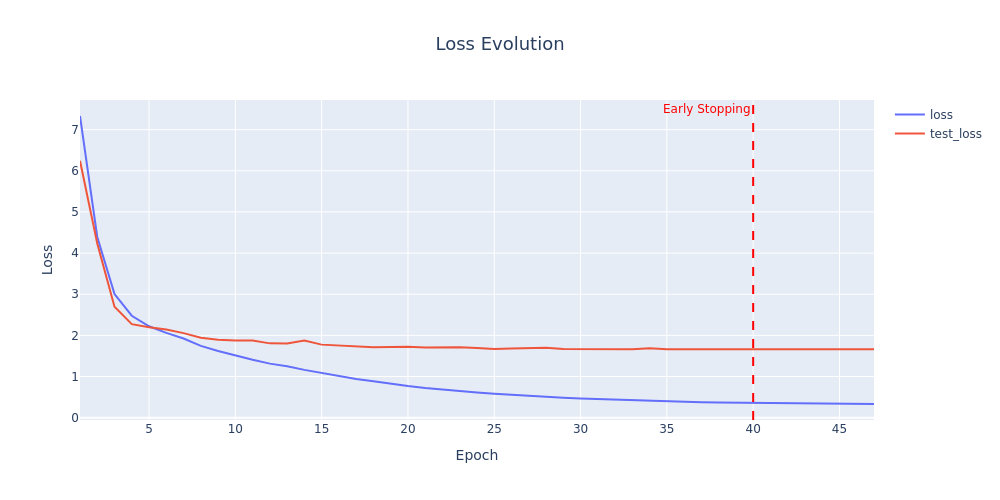

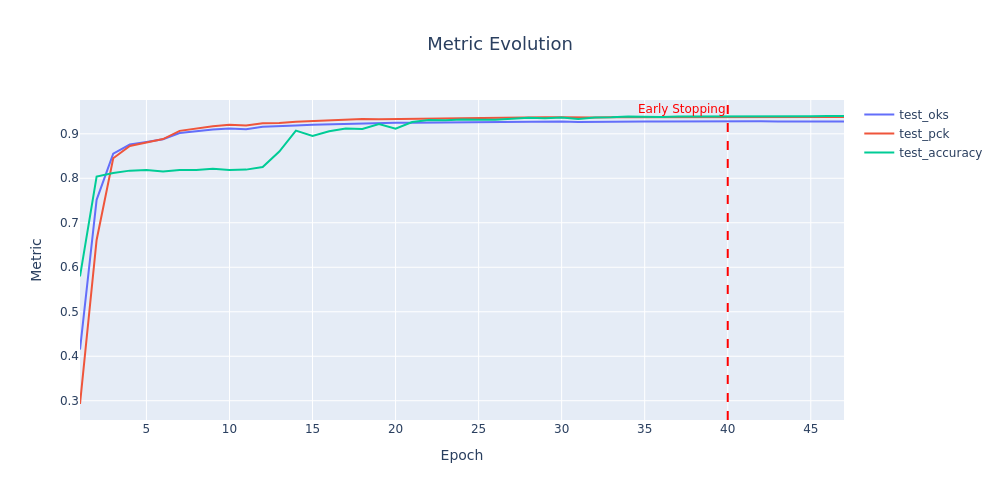

In [ ]:
# Static images for GitHub
plot_training_curves(history, history.columns[[0, 2]], idxmax, "png")
plot_training_curves(history, history.columns[3:], idxmax, "png")

### **Visualizing Pose Predictions**

In [ ]:
results = np.load(os.path.join(args.ckpt_dir, "inf_test_results_8d.npz"))

visualizer = PoseVisualizer(args.skeleton)
oks_metric = OKSMetric(args.oks_sigmas)
pck_metric = PCKMetric(args.alpha)

for k, v in results.items():
    print(k, v.shape)

images (5776, 384, 384, 3)
keypoints (5776, 15, 3)
bboxes (5776, 4)
keypoints_pred (5776, 15, 3)


In [ ]:
args.skeleton

{'back': [0, 9],
 'beak': [1, 1],
 'belly': [2, 3],
 'breast': [3, 14],
 'crown': [4, 5],
 'forehead': [5, 1],
 'left eye': [6, 5],
 'left leg': [7, 2],
 'left wing': [8, 0],
 'nape': [9, 4],
 'right eye': [10, 5],
 'right leg': [11, 2],
 'right wing': [12, 0],
 'tail': [13, 0],
 'throat': [14, 1]}

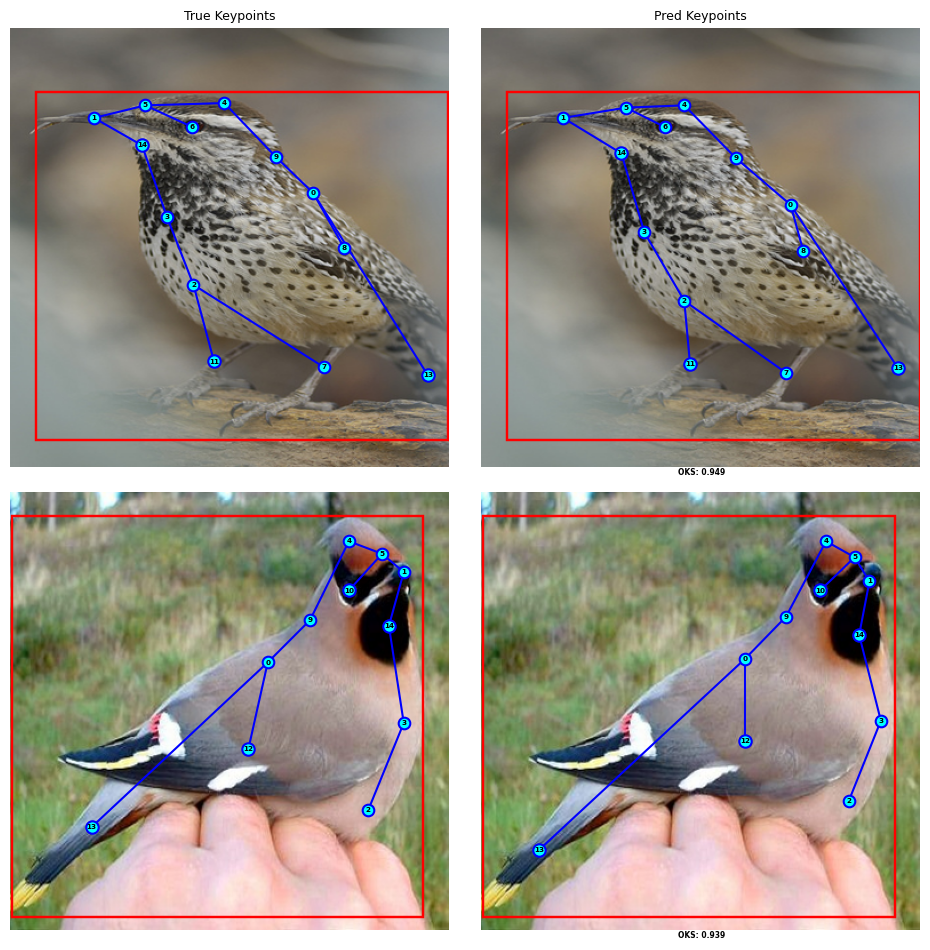

In [ ]:
visualizer.plot_keypoints(results, oks_metric)

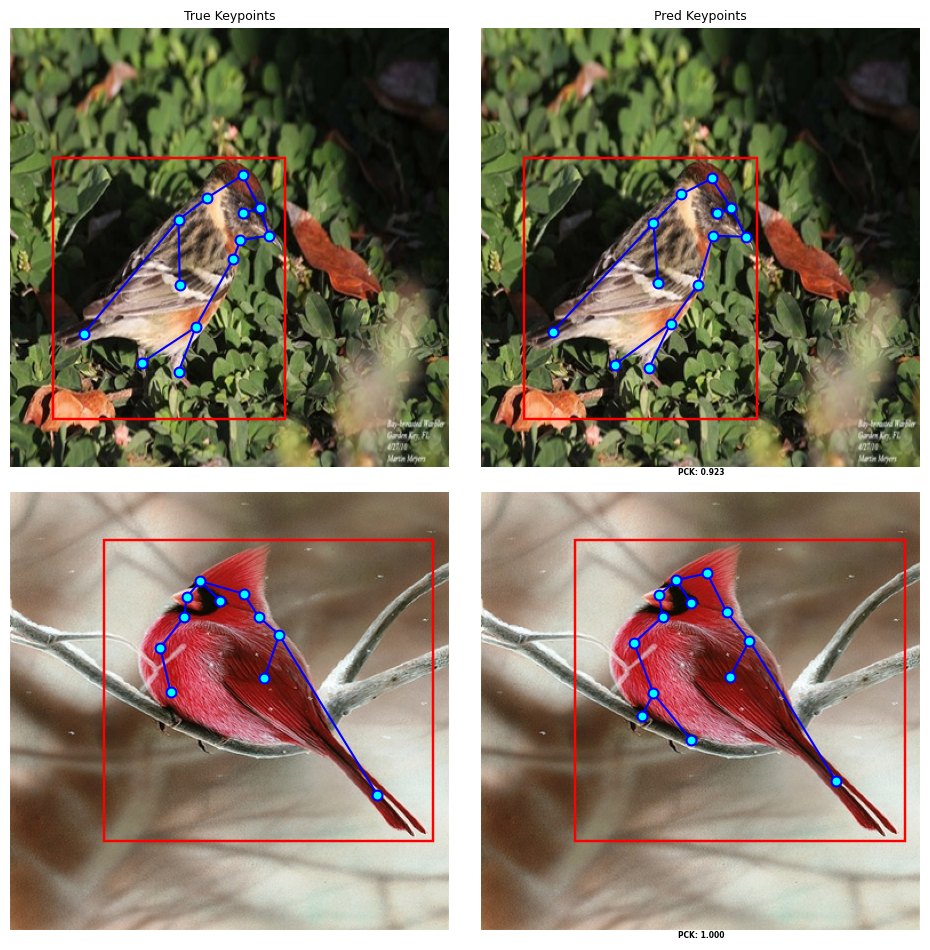

In [ ]:
visualizer.plot_keypoints(results, pck_metric, show_kpts_ids=False)

## **Final Model Evaluation (Single-Device)**

In distributed training with **PyTorch/XLA**, when creating a `DistributedSampler` for a dataset whose size is not divisible by the `world_size` (the number of processes, i.e., TPU cores), it is recommended to set `drop_last=True` to prevent sample duplication during training, evaluation, and inference. Additionally, when defining the `DataLoader`, it is also advisable to discard the remaining incomplete batch using `drop_last=True`. This is because, in **PyTorch/XLA**, compiling a final batch of different size is computationally expensive in both memory and execution time, especially when it belongs to the training `DataLoader`. Therefore, after distributed training, it is preferable to perform the full model evaluation on a single device to ensure that no samples from the validation or test set are dropped.

It is worth noting that single-device evaluation may slightly differ from multi-device evaluation due to:

* The samples discarded during distributed training.
* Differences in batch size (smaller on a single device).
* Floating-point accumulation errors (e.g., floating-point addition is non-associative), which can cause minor variations in metric computations.

In [ ]:
!python train_xla.py \
    --single_process \
    --run_mode "evaluation" \
    --data_dir {data_dir} \
    --batch_size 32 \
    --num_workers {args.num_workers // 8} \
    --eval_set "test"

Devices available for evaluation:
 xla:0 (16126 MiB)

Test dataset: size=5781, deleted_records=0

Total parameters of the trained model: 103,204,175

Test: 100%|██████████| 181/181 [01:46<00:00,  1.70it/s, test_loss=1.67, test_oks=0.928, test_pck=0.939, test_accuracy=0.939]


In [ ]:
# Load and compare multi-device vs single-device evaluation results
pd.DataFrame(
    [
        pd.read_csv(os.path.join(args.ckpt_dir, "test_results_8d.csv")).values.squeeze(),
        pd.read_csv(os.path.join(args.ckpt_dir, "test_results_1d.csv")).values.squeeze()
    ],
    columns=["Loss", "OKS", f"PCK@{args.alpha}", "Visibility Accuracy"],
    index=["multi-device evaluation", "complete evaluation"]
)

,Loss,OKS,PCK@0.05,Visibility Accuracy
multi-device evaluation,1.664962,0.928189,0.938476,0.93877
complete evaluation,1.666978,0.928162,0.938534,0.93880


## **Appendix: Single-Device Training (Google Colab)**

Additionally, as a complementary experiment, the model will be trained for only 5 epochs using the **TPU v5e-1** available in Google Colab. Since this TPU has only a single core, the model's input dimensions are reduced to **(256, 256)** to prevent memory issues and speed up the experimental run.

In [1]:
data_dir = "CUB-200-2011"
batch_size = 16

In [2]:
!python train_xla.py \
    --data_dir {data_dir} \
    --epochs 5 \
    --batch_size {batch_size} \
    --img_size 256 256 \
    --kernel_size 33 33 \
    --heatmap_sigma 6.0 \
    --lrf 7.5e-4 \
    --eval_set "test" \
    --monitor "test_oks"

WARNING ⚠️: Only one XLA device detected. Switching to single-process mode.

Devices available for training:
 xla:0 (16126 MiB)

model.safetensors: 100% 354M/354M [00:01<00:00, 178MB/s]
Train dataset: size=5990, deleted_records=6
 Test dataset: size=5781, deleted_records=0

Total model parameters: 103,204,175

Epoch 1/5
 Test: 100%|██████████| 362/362 [03:51<00:00,  1.56it/s, test_loss=4.28, test_oks=0.673, test_pck=0.614, test_accuracy=0.73]

Epoch 2/5
 Test: 100%|██████████| 362/362 [00:41<00:00,  8.76it/s, test_loss=3.57, test_oks=0.754, test_pck=0.711, test_accuracy=0.788]

Epoch 3/5
 Test: 100%|██████████| 362/362 [00:42<00:00,  8.61it/s, test_loss=3.23, test_oks=0.789, test_pck=0.758, test_accuracy=0.775]

Epoch 4/5
 Test: 100%|██████████| 362/362 [00:41<00:00,  8.70it/s, test_loss=3.01, test_oks=0.803, test_pck=0.778, test_accuracy=0.791]

Epoch 5/5
 Test: 100%|██████████| 362/362 [00:42<00:00,  8.46it/s, test_loss=2.81, test_oks=0.823, test_pck=0.803, test_accuracy=0.793]



In [ ]:
# Approximate speedup ratio: multi-device GPU epoch time (T4x2 GPUs) / single-device XLA epoch time (TPU v5e-1)
round((4*60 + 28 + 1*60 + 33) / (2*60 + 38 + 42), 2)

1.8

It can be observed that training on a single core of the **TPU v5e-1** is approximately **1.8x** faster than distributed training on **two Tesla T4 GPUs**, using the same input size **(256, 256)**, as shown in the following [notebook](https://github.com/JersonGB22/PoseEstimation-TensorFlow-PyTorch/blob/main/pytorch_xla_ddp/PoseEstimation_PyTorchDDP_MultiGPU.ipynb). Although the **TPU v5e-1** has **16 GB of HBM**, roughly equivalent to the **15 GB of VRAM** on each **T4 GPU**, the results demonstrate that even a single TPU core outperforms two Tesla T4 GPUs. 

## **Conclusion**

Using distributed training with **PyTorch/XLA** on Kaggle's **TPU v5e-8**, the **ConvNeXtBase U-Net** model with over **100 million parameters**, achieved an **OKS** of **0.928**, a **PCK@0.05** of **0.939**, and a **Visibility Accuracy** of **0.939** on the test set. These results are comparable to those obtained with **TensorFlow** distributed training, but with an **approximately 9.62x faster** execution time. Moreover, this pipeline can be seamlessly applied to any phase, **training**, **validation**, or **inference** in *multi-device* environments using **PyTorch/XLA**.

It was also observed that even a **single TPU core**, when trained with **PyTorch/XLA**, can outperform multiple **GPUs** using PyTorch's **DDP** strategy. Altogether, these findings highlight the efficiency, scalability, and high performance of TPUs combined with **PyTorch/XLA** for **Computer Vision** tasks and, more broadly, for any **Deep Learning** workload.